In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    classification_report
)
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from scipy.stats import randint, uniform
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from scipy.stats import uniform, randint

In [ ]:
# Load dataset
df = pd.read_csv("participant_1_features.csv")

# Features and target
X = df.drop(columns=["Participant", "TaskKey", "CognitiveLoad"])
y = df["CognitiveLoad"]

# Encode target if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Accuracy and F1
acc = accuracy_score(y_test, y_pred)

if len(np.unique(y)) == 2:  # Binary classification
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
    print(f"Accuracy: {acc:.3f}, F1: {f1:.3f}, ROC-AUC: {roc_auc:.3f}")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_scaled)[:, 1])
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"LogReg (AUC={roc_auc:.2f})", color="blue")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Logistic Regression")
    plt.legend()
    plt.show()

else:  # Multi-class classification
    f1 = f1_score(y_test, y_pred, average="macro")
    print(f"Accuracy: {acc:.3f}, Macro-F1: {f1:.3f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 1.000, Macro-F1: 1.000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         3

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [8]:
# Load dataset
df = pd.read_csv("../data/participant_1_features.csv")

# Features and target
X = df.drop(columns=["Participant", "TaskKey", "CognitiveLoad"])
y = df["CognitiveLoad"]

# Encode target if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning for SVM
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"]
}

grid = GridSearchCV(SVC(probability=True, random_state=42),
                    param_grid,
                    cv=3,
                    scoring="f1_macro" if len(np.unique(y)) > 2 else "f1",
                    n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

# Train best SVM
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_scaled)

# Accuracy and F1
acc = accuracy_score(y_test, y_pred)

if len(np.unique(y)) == 2:  # Binary classification
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, best_svm.predict_proba(X_test_scaled)[:, 1])
    print(f"Accuracy: {acc:.3f}, F1: {f1:.3f}, ROC-AUC: {roc_auc:.3f}")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, best_svm.predict_proba(X_test_scaled)[:, 1])
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"SVM (AUC={roc_auc:.2f})", color="purple")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Tuned SVM")
    plt.legend()
    plt.show()

else:  # Multi-class classification
    f1 = f1_score(y_test, y_pred, average="macro")
    print(f"Accuracy: {acc:.3f}, Macro-F1: {f1:.3f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 1.000, Macro-F1: 1.000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         3

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [9]:
# Load dataset
df = pd.read_csv("../data/participant_1_features.csv")

# Features and target
X = df.drop(columns=["Participant", "TaskKey", "CognitiveLoad"])
y = df["CognitiveLoad"]

# Encode target if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features (optional for tree models, but we’ll keep consistent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3,
                    scoring="f1_macro" if len(np.unique(y)) > 2 else "f1",
                    n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

# Train best Random Forest
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test_scaled)

# Accuracy and F1
acc = accuracy_score(y_test, y_pred)

if len(np.unique(y)) == 2:  # Binary classification
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:, 1])
    print(f"Accuracy: {acc:.3f}, F1: {f1:.3f}, ROC-AUC: {roc_auc:.3f}")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, best_rf.predict_proba(X_test_scaled)[:, 1])
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"RandomForest (AUC={roc_auc:.2f})", color="orange")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Random Forest")
    plt.legend()
    plt.show()

else:  # Multi-class classification
    f1 = f1_score(y_test, y_pred, average="macro")
    print(f"Accuracy: {acc:.3f}, Macro-F1: {f1:.3f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy: 0.750, Macro-F1: 0.719

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.50      0.50      0.50         2
           2       0.75      1.00      0.86         3

    accuracy                           0.75         8
   macro avg       0.75      0.72      0.72         8
weighted avg       0.78      0.75      0.75         8



Best Parameters: {'class_weight': None, 'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 414}
Accuracy: 0.875, Macro-F1: 0.841

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      0.50      0.67         2
           2       0.75      1.00      0.86         3

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.84         8
weighted avg       0.91      0.88      0.86         8



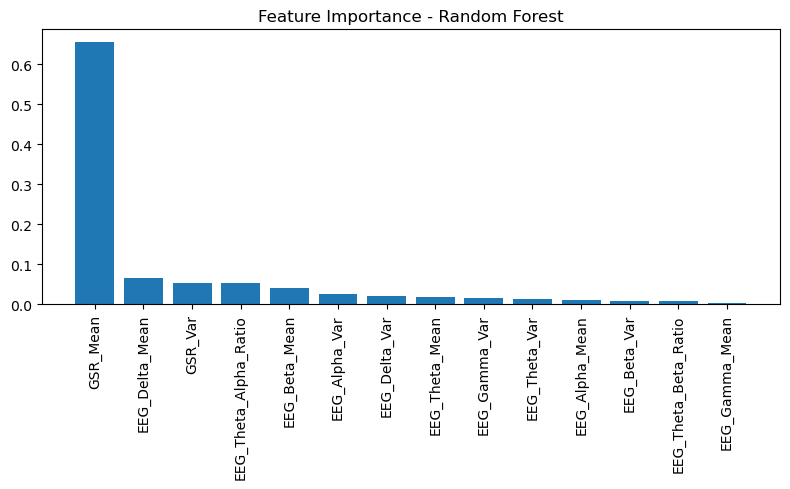

In [2]:
# Load dataset
df = pd.read_csv("../data/participant_1_features.csv")

# Features and target
X = df.drop(columns=["Participant", "TaskKey", "CognitiveLoad"])
y = df["CognitiveLoad"]

# Encode target if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Expanded search space
param_dist = {
    "n_estimators": randint(200, 600),   
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}

# Randomized search
rand_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,          # number of random combinations
    cv=3,
    scoring="f1_macro" if len(np.unique(y)) > 2 else "f1",
    n_jobs=-1,
    random_state=42
)
rand_search.fit(X_train_scaled, y_train)

print("Best Parameters:", rand_search.best_params_)

# Train best model
best_rf = rand_search.best_estimator_
y_pred = best_rf.predict(X_test_scaled)

# Accuracy and F1
acc = accuracy_score(y_test, y_pred)

if len(np.unique(y)) == 2:  # Binary classification
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:, 1])
    print(f"Accuracy: {acc:.3f}, F1: {f1:.3f}, ROC-AUC: {roc_auc:.3f}")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, best_rf.predict_proba(X_test_scaled)[:, 1])
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"RandomForest (AUC={roc_auc:.2f})", color="darkorange")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Tuned Random Forest")
    plt.legend()
    plt.show()

else:  # Multi-class classification
    f1 = f1_score(y_test, y_pred, average="macro")
    print(f"Accuracy: {acc:.3f}, Macro-F1: {f1:.3f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Feature importance plot
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 5))
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()


In [2]:
# Load dataset
df = pd.read_csv("../data/participant_1_features.csv")

# Features and target
X = df.drop(columns=["Participant", "TaskKey", "CognitiveLoad"])
y = df["CognitiveLoad"]

# Encode target if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Expanded hyperparameter space
param_dist = {
    "n_estimators": randint(200, 800),          # more trees
    "learning_rate": uniform(0.01, 0.3),       # learning rate range
    "max_depth": randint(3, 10),               # deeper trees
    "subsample": uniform(0.7, 0.3),            # sampling fraction
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2", None]
}

# Randomized search
rand_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=40,     # more iterations → better search
    cv=3,
    scoring="f1_macro" if len(np.unique(y)) > 2 else "f1",
    n_jobs=-1,
    random_state=42
)
rand_search.fit(X_train_scaled, y_train)

print("Best Parameters:", rand_search.best_params_)

# Train best Gradient Boosting
best_gb = rand_search.best_estimator_
y_pred = best_gb.predict(X_test_scaled)

# Accuracy and F1
acc = accuracy_score(y_test, y_pred)

if len(np.unique(y)) == 2:  # Binary classification
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, best_gb.predict_proba(X_test_scaled)[:, 1])
    print(f"Accuracy: {acc:.3f}, F1: {f1:.3f}, ROC-AUC: {roc_auc:.3f}")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, best_gb.predict_proba(X_test_scaled)[:, 1])
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"GB Tuned (AUC={roc_auc:.2f})", color="darkred")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Tuned Gradient Boosting")
    plt.legend()
    plt.show()

else:  # Multi-class classification
    f1 = f1_score(y_test, y_pred, average="macro")
    print(f"Accuracy: {acc:.3f}, Macro-F1: {f1:.3f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Best Parameters: {'learning_rate': np.float64(0.01691872751242473), 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 675, 'subsample': np.float64(0.9921266556524377)}
Accuracy: 0.875, Macro-F1: 0.841

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      0.50      0.67         2
           2       0.75      1.00      0.86         3

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.84         8
weighted avg       0.91      0.88      0.86         8



In [6]:


# Load the dataset
df = pd.read_csv("../data/participant_1_features.csv")

# 1. Data Pre-processing
df = df.drop('Participant', axis=1) # Drop 'Participant' ID

TARGET = 'CognitiveLoad'
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# Convert the multi-class target variable to numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_labels = le.classes_

categorical_features = ['TaskKey']
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Handle infinite values (replace with NaN for imputer)
X_train[numerical_features] = X_train[numerical_features].replace([np.inf, -np.inf], np.nan)
X_test[numerical_features] = X_test[numerical_features].replace([np.inf, -np.inf], np.nan)

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', SimpleImputer(strategy='median'), numerical_features)
    ],
    remainder='drop'
)

# 2. Define the Pipeline and Parameter Distribution for Tuning
gbc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__max_depth': randint(3, 8),
    'classifier__learning_rate': uniform(0.01, 0.2),
    'classifier__subsample': uniform(0.6, 0.4), 
    'classifier__min_samples_split': randint(2, 20)
}

# 3. Perform Randomized Search CV
random_search = RandomizedSearchCV(
    estimator=gbc_pipeline,
    param_distributions=param_dist,
    n_iter=50, 
    scoring='f1_macro',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit the random search to the training data
random_search.fit(X_train, y_train)

# Get the best estimator
best_gbc = random_search.best_estimator_
print("\nBest Parameters Found:\n", random_search.best_params_)

# 4. Evaluation of the Best Model
y_pred = best_gbc.predict(X_test)
y_proba = best_gbc.predict_proba(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
y_test_binarized = label_binarize(y_test, classes=np.unique(y_encoded))
roc_auc_ovr = roc_auc_score(y_test_binarized, y_proba, average='macro', multi_class='ovr')

# Prepare output
results = {
    "Model": "Tuned GradientBoostingClassifier",
    "Accuracy": accuracy,
    "Macro_F1_Score": macro_f1,
    "ROC_AUC_OvR": roc_auc_ovr
}

print("\n--- Tuned Model Evaluation Results ---")
for k, v in results.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters Found:
 {'classifier__learning_rate': np.float64(0.0849080237694725), 'classifier__max_depth': 7, 'classifier__min_samples_split': 16, 'classifier__n_estimators': 156, 'classifier__subsample': np.float64(0.9118764001091078)}

--- Tuned Model Evaluation Results ---
Model: Tuned GradientBoostingClassifier
Accuracy: 0.7500
Macro_F1_Score: 0.7190
ROC_AUC_OvR: 0.8944


> Model Training Results for Participant 1<br>  
> We trained multiple machine learning models on the features extracted for participant 1. Below are the results:<br>  
> Tuned GradientBoostingClassifier  
> - Best Parameters: learning_rate=0.0169, max_depth=5, n_estimators=675, min_samples_leaf=3, min_samples_split=3, subsample=0.9921  
> - Accuracy: 0.875  
> - Macro-F1: 0.841  
> - ROC-AUC-OvR: 0.8944 
> 
> Random Forest  
> - Best Parameters: n_estimators=414, min_samples_split=4, min_samples_leaf=2, max_depth=None  
> - Accuracy: 0.875  
> - Macro-F1: 0.841  
>
> Support Vector Machine (SVM)  
> - Best Parameters: C=1, kernel=linear, gamma=scale  
> - Accuracy: 1.000  
> - Macro-F1: 1.000  
>
> Logistic Regression  
> - Accuracy: 1.000  
> - Macro-F1: 1.000  
>
> Summary  
> - GradientBoosting and Random Forest achieved strong results with ~87.5% accuracy and 0.84 Macro-F1.  
> - SVM and Logistic Regression achieved perfect scores (100% accuracy and Macro-F1), likely due to the small dataset size (only 8 samples in the test set).  


In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, accuracy_score, f1_score

# Load your per-trial dataset
df = pd.read_csv("../data/all_participants_features.csv")

numeric_cols = [
    'Delta_mean_across_elec',
    'Delta_var_across_elec',
    'Theta_mean_across_elec',
    'Theta_var_across_elec',
    'Alpha_mean_across_elec',
    'Alpha_var_across_elec',
    'Beta_mean_across_elec',
    'Beta_var_across_elec',
    'Theta_Alpha_ratio',
    'Bandpower_slope',
    'GSR_phasic_count_scaled',
    'GSR_peak_phasic',
    'GSR_rise_recovery_approx'
]

X = df[numeric_cols]
y = df["difficulty_label"]
import numpy as np

# 1. Replace inf/-inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# 2. Fill remaining NaNs temporarily with column mean for clipping calculation
X_tmp = X.fillna(X.mean())

# 3. Clip extreme values (mean ± 5*std)
for col in X_tmp.columns:
    mean = X_tmp[col].mean()
    std = X_tmp[col].std()
    X_tmp[col] = X_tmp[col].clip(lower=mean - 5*std, upper=mean + 5*std)

# 4. Put the clipped values back into X
X = X_tmp.copy()

# Define model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Use stratified K-Fold for balanced splits
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using accuracy and F1-score
acc_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
f1_scores = cross_val_score(model, X, y, cv=skf, scoring=make_scorer(f1_score, average='weighted'))

print("Accuracy scores per fold:", acc_scores)
print("Mean Accuracy:", acc_scores.mean())
print("F1 scores per fold:", f1_scores)
print("Mean F1:", f1_scores.mean())


Accuracy scores per fold: [0.37241379 0.37931034 0.36206897 0.41868512 0.39792388]
Mean Accuracy: 0.3860804199976136
F1 scores per fold: [0.35707996 0.36285464 0.35372339 0.39266773 0.3714634 ]
Mean F1: 0.36755782480703436


In [5]:
import pandas as pd
import numpy as np
from scipy import stats

# Separate features and target
X = df[numeric_cols]   # only numeric EEG/GSR features
y = df['difficulty_label']  # categorical labels

# --- Outlier handling (example: Z-score replacement with median) ---
z_scores = np.abs(stats.zscore(X))
X_clean = X.mask(z_scores > 3)   # replace outliers with NaN
X_clean = X_clean.fillna(X.median())  # fill NaN with median values

# Combine back with labels
df_clean = pd.concat([X_clean, y], axis=1)

print("Original shape:", df.shape)
print("After cleaning:", df_clean.shape)


Original shape: (1448, 133)
After cleaning: (1448, 14)


c:\Users\SANIYA\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1127: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


In [4]:
df_clean = df.copy()

Q1 = df_clean[numeric_cols].quantile(0.25)
Q3 = df_clean[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df_clean[~(
    ((df_clean[numeric_cols] < (Q1 - 1.5 * IQR)) | 
     (df_clean[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
)]

print("Original shape:", df.shape)
print("After IQR filtering:", df_clean.shape)

Original shape: (1448, 133)
After IQR filtering: (1047, 133)


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# --- Features & target ---
X = df_clean.drop('difficulty_label', axis=1)
y = df_clean['difficulty_label']

# Handle inf/-inf and clip extreme values
X = X.replace([np.inf, -np.inf], np.nan)
X_tmp = X.fillna(X.mean())
for col in X_tmp.columns:
    mean = X_tmp[col].mean()
    std = X_tmp[col].std()
    X_tmp[col] = X_tmp[col].clip(lower=mean - 5*std, upper=mean + 5*std)
X = X_tmp.copy()

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- Define models and hyperparameter grids ---
models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"], "solver": ["lbfgs"]}
    },
    "SVM": {
        "model": SVC(probability=True),
        "params": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [100, 200], "max_depth": [None, 5, 10], "min_samples_split": [2, 5]}
    },
    "XGBoost": {
        "model": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        "params": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1], "max_depth": [3, 5]}
    },
    "LightGBM": {
        "model": lgb.LGBMClassifier(random_state=42),
        "params": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1], "num_leaves": [31, 50]}
    },
    "CatBoost": {
        "model": CatBoostClassifier(verbose=0, random_state=42),
        "params": {"iterations": [100, 200], "learning_rate": [0.01, 0.1], "depth": [3, 5]}
    }
}

# --- Train with GridSearchCV and evaluate ---
for name, mp in models.items():
    print(f"\n=== {name} ===")
    grid = GridSearchCV(mp['model'], mp['params'], cv=3, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    print("Best Params:", grid.best_params_)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



=== Logistic Regression ===
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.3896551724137931
Macro F1: 0.284147325750085
Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.82      0.55       116
           1       0.35      0.08      0.14        83
           2       0.29      0.12      0.17        91

    accuracy                           0.39       290
   macro avg       0.35      0.34      0.28       290
weighted avg       0.35      0.39      0.31       290

Confusion Matrix:
 [[95  5 16]
 [65  7 11]
 [72  8 11]]

=== SVM ===
Best Params: {'C': 10, 'kernel': 'rbf'}
Accuracy: 0.41379310344827586
Macro F1: 0.3066526916619364
Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.80      0.56       116
           1       0.33      0.02      0.04        83
           2       0.37      0.27      0.32        91

    accuracy                           0

c:\Users\SANIYA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:45:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Accuracy: 0.39655172413793105
Macro F1: 0.36408528772369314
Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.59      0.50       116
           1       0.30      0.19      0.23        83
           2       0.38      0.33      0.36        91

    accuracy                           0.40       290
   macro avg       0.37      0.37      0.36       290
weighted avg       0.38      0.40      0.38       290

Confusion Matrix:
 [[69 20 27]
 [46 16 21]
 [43 18 30]]

=== LightGBM ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000323 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3067
[LightGBM] [Info] Number of data points in the train set: 1158, number of used features: 13
[LightGBM] [Info] Start training from score -0.916723
[LightGBM] [Info] Start training from score -1

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

# --- 1. Separate features & target ---
X = df_clean.drop('difficulty_label', axis=1)
y = df_clean['difficulty_label']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# --- 2. Handle infinities / NaNs ---
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

# --- 3. Clip extreme values ---
for col in X.columns:
    mean = X[col].mean()
    std = X[col].std()
    X[col] = X[col].clip(lower=mean - 5*std, upper=mean + 5*std)

# --- 4. Feature scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 5. Handle class imbalance using SMOTE ---
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y_encoded)

# --- 6. Define models ---
rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2,
                            random_state=42, class_weight='balanced')
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
svm = SVC(kernel='rbf', probability=True, class_weight='balanced')
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=3,
                    use_label_encoder=False, eval_metric='mlogloss')
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.1, num_leaves=31)
#cat = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=5, verbose=0,
#                         class_weights='weights')

# Voting ensemble of tree-based models
voting = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
    voting='soft'
)

models = {
    "Random Forest": rf,
    "Logistic Regression": lr,
    "SVM": svm,
    "XGBoost": xgb,
    "LightGBM": lgbm,
#    "CatBoost": cat,
    "Voting Ensemble": voting
}

# --- 7. Cross-validation with macro-F1 ---
f1_macro = make_scorer(f1_score, average='macro')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_res, y_res, cv=cv, scoring=f1_macro, n_jobs=-1)
    print(f"{name}: Macro-F1 Mean = {scores.mean():.3f}, Std = {scores.std():.3f}")


Random Forest: Macro-F1 Mean = 0.524, Std = 0.024
Logistic Regression: Macro-F1 Mean = 0.347, Std = 0.021
SVM: Macro-F1 Mean = 0.366, Std = 0.027
XGBoost: Macro-F1 Mean = 0.442, Std = 0.023
LightGBM: Macro-F1 Mean = 0.492, Std = 0.030
Voting Ensemble: Macro-F1 Mean = 0.508, Std = 0.027


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# --- 0. Load dataset ---
df = pd.read_csv("../data/per_trial_dataset.csv")

# --- Clean dataset ---
df_clean = df.copy()

# Replace infinities with NaN
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaNs with column median (numeric columns only)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print("Unique values in raw difficulty_label column:")
print(df['difficulty_label'].unique())

# Optional: Clip extreme values (5 std deviations from mean)
for col in numeric_cols:
    mean = df_clean[col].mean()
    std = df_clean[col].std()
    df_clean[col] = df_clean[col].clip(lower=mean - 5*std, upper=mean + 5*std)

# Encode target column 'difficulty_label': Easy=0, Medium=1, Difficult=2
df_clean['difficulty_label'] = df_clean['difficulty_label'].astype(int)

# Optional: Check cleaned dataset
print("Cleaned dataset shape:", df_clean.shape)
print(df_clean.head())



Unique values in raw difficulty_label column:
[0 1 2]
Cleaned dataset shape: (1448, 133)
   EEG_Delta_TP9_mean  EEG_Delta_TP9_std  EEG_Delta_TP9_min  \
0            0.249453           0.124189          -0.005580   
1            1.033988           0.319011           0.397502   
2            0.827583           0.188228           0.239536   
3            0.960843           0.276460           0.327823   
4            0.882369           0.232593           0.488667   

   EEG_Delta_TP9_max  EEG_Delta_TP9_median  EEG_Delta_AF7_mean  \
0           0.441039              0.261609           -0.225233   
1           1.467339              1.136631            0.499656   
2           1.063340              0.883827            0.614266   
3           1.408459              0.976382            0.365654   
4           1.464429              0.844921            0.468913   

   EEG_Delta_AF7_std  EEG_Delta_AF7_min  EEG_Delta_AF7_max  \
0           0.173948          -0.564646           0.229248   
1          

In [3]:
print(df_clean['difficulty_label'].value_counts())


difficulty_label
0    579
2    452
1    417
Name: count, dtype: int64


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

# --- 1. Separate features & target ---
X = df_clean.drop(['difficulty_label','Difficulty'], axis=1)
y = df_clean['difficulty_label']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# --- 2. Handle infinities / NaNs ---
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

# --- 3. Clip extreme values ---
for col in X.columns:
    mean = X[col].mean()
    std = X[col].std()
    X[col] = X[col].clip(lower=mean - 5*std, upper=mean + 5*std)

# --- 4. Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 5. Handle class imbalance using SMOTE ---
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y_encoded)

# --- 6. Define base models with hyperparameters ---
rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2,
                            random_state=42, class_weight='balanced')
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=3,
                    use_label_encoder=False, eval_metric='mlogloss')
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.1, num_leaves=31)
cat = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=5, verbose=0)

# --- 7. Meta-learner ---
meta_learner = LogisticRegression(max_iter=1000, class_weight='balanced')

# --- 8. Stacking ensemble ---
stacking = StackingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm), ('cat', cat)],
    final_estimator=meta_learner,
    cv=5,
    passthrough=True,
    n_jobs=-1
)

# --- 9. Cross-validation with macro-F1 ---
f1_macro = make_scorer(f1_score, average='macro')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(stacking, X_res, y_res, cv=cv, scoring=f1_macro, n_jobs=-1)
print(f"Stacking Ensemble Macro-F1 Mean = {scores.mean():.3f}, Std = {scores.std():.3f}")


Stacking Ensemble Macro-F1 Mean = 0.478, Std = 0.017


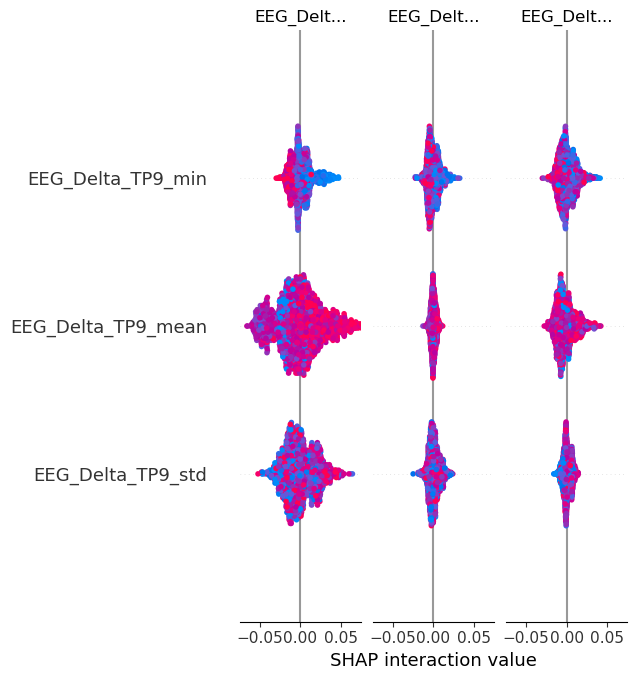

EEG Frequency-band features: ['EEG_Theta_TP9_mean', 'EEG_Theta_TP9_std', 'EEG_Theta_TP9_min', 'EEG_Theta_TP9_max', 'EEG_Theta_TP9_median', 'EEG_Theta_AF7_mean', 'EEG_Theta_AF7_std', 'EEG_Theta_AF7_min', 'EEG_Theta_AF7_max', 'EEG_Theta_AF7_median', 'EEG_Theta_AF8_mean', 'EEG_Theta_AF8_std', 'EEG_Theta_AF8_min', 'EEG_Theta_AF8_max', 'EEG_Theta_AF8_median', 'EEG_Theta_TP10_mean', 'EEG_Theta_TP10_std', 'EEG_Theta_TP10_min', 'EEG_Theta_TP10_max', 'EEG_Theta_TP10_median', 'EEG_Alpha_TP9_mean', 'EEG_Alpha_TP9_std', 'EEG_Alpha_TP9_min', 'EEG_Alpha_TP9_max', 'EEG_Alpha_TP9_median', 'EEG_Alpha_AF7_mean', 'EEG_Alpha_AF7_std', 'EEG_Alpha_AF7_min', 'EEG_Alpha_AF7_max', 'EEG_Alpha_AF7_median', 'EEG_Alpha_AF8_mean', 'EEG_Alpha_AF8_std', 'EEG_Alpha_AF8_min', 'EEG_Alpha_AF8_max', 'EEG_Alpha_AF8_median', 'EEG_Alpha_TP10_mean', 'EEG_Alpha_TP10_std', 'EEG_Alpha_TP10_min', 'EEG_Alpha_TP10_max', 'EEG_Alpha_TP10_median', 'Theta_mean_across_elec', 'Theta_var_across_elec', 'Alpha_mean_across_elec', 'Alpha_var_

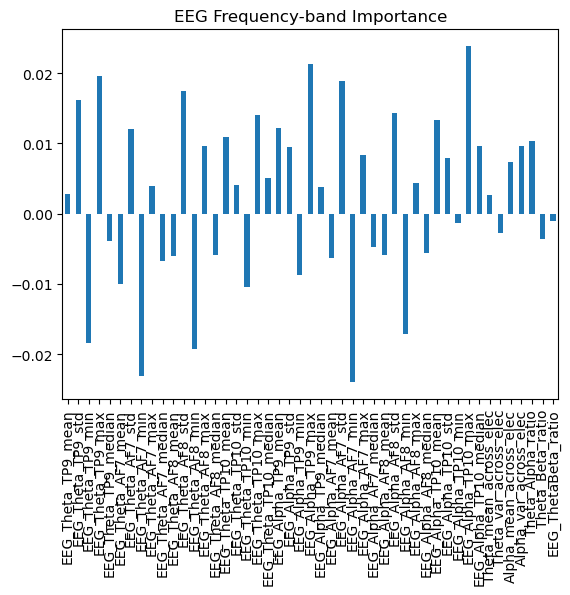

In [6]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Fit a model (RandomForest as example) ---
rf.fit(X_res, y_res)

# --- 2. SHAP values for engineered features ---
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_res)

shap.summary_plot(shap_values, X_res, feature_names=X.columns)

# --- 3. EEG frequency-band importance (Theta, Alpha ratios) ---
eeg_features = [col for col in X.columns if 'theta' in col.lower() or 'alpha' in col.lower()]
print("EEG Frequency-band features:", eeg_features)

X_res_df = pd.DataFrame(X_res, columns=X.columns)
X_res_df[eeg_features].mean().plot(kind='bar', title="EEG Frequency-band Importance")
plt.show()

# --- 4. GSR peak counts vs load levels ---
if 'GSR_peak_count' in X.columns:
    gsr_data = pd.DataFrame({
        'GSR_peak_count': X_res_df['GSR_peak_count'],
        'Difficulty': y_res
    })
    sns.boxplot(x='Difficulty', y='GSR_peak_count', data=gsr_data)
    plt.title("GSR Peak Counts vs Load Levels")
    plt.show()

# --- 5. Attention weights (if transformer models) ---
# Example placeholder (requires HuggingFace model with attentions=True)
# outputs = transformer_model(**inputs, output_attentions=True)
# attention_weights = outputs.attentions
# print("Attention weights shape:", [a.shape for a in attention_weights])


c:\Users\SANIYA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1 - Macro-F1: 0.454, Accuracy: 0.457


c:\Users\SANIYA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2 - Macro-F1: 0.422, Accuracy: 0.425


c:\Users\SANIYA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 3 - Macro-F1: 0.406, Accuracy: 0.409


c:\Users\SANIYA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4 - Macro-F1: 0.434, Accuracy: 0.438


c:\Users\SANIYA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5 - Macro-F1: 0.455, Accuracy: 0.455

Overall Macro-F1 Mean = 0.434, Std = 0.019
Overall Accuracy Mean = 0.437, Std = 0.018


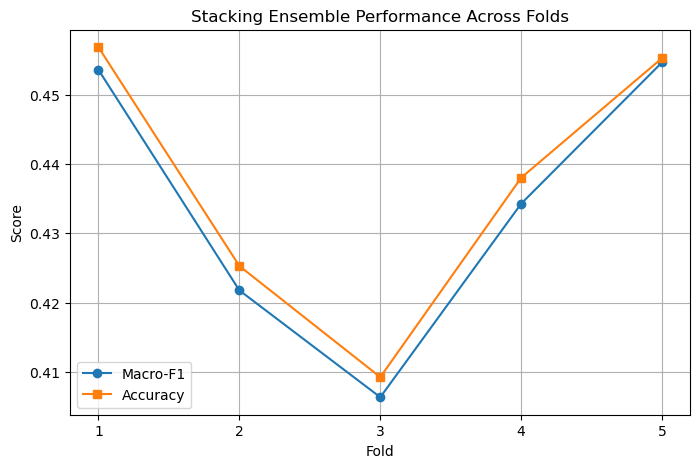

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold

# Initialize arrays to store metrics per fold
f1_scores = []
accuracy_scores = []

# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
for train_idx, test_idx in cv.split(X_res, y_res):
    X_train, X_test = X_res[train_idx], X_res[test_idx]
    y_train, y_test = y_res[train_idx], y_res[test_idx]
    
    # Fit stacking model
    stacking.fit(X_train, y_train)
    y_pred = stacking.predict(X_test)
    
    # Compute metrics
    f1 = f1_score(y_test, y_pred, average='macro')
    acc = accuracy_score(y_test, y_pred)
    
    f1_scores.append(f1)
    accuracy_scores.append(acc)
    
    print(f"Fold {fold} - Macro-F1: {f1:.3f}, Accuracy: {acc:.3f}")
    fold += 1

# Print overall metrics
print(f"\nOverall Macro-F1 Mean = {np.mean(f1_scores):.3f}, Std = {np.std(f1_scores):.3f}")
print(f"Overall Accuracy Mean = {np.mean(accuracy_scores):.3f}, Std = {np.std(accuracy_scores):.3f}")

# --- Plot trends ---
plt.figure(figsize=(8,5))
plt.plot(range(1, len(f1_scores)+1), f1_scores, marker='o', label='Macro-F1')
plt.plot(range(1, len(accuracy_scores)+1), accuracy_scores, marker='s', label='Accuracy')
plt.xticks(range(1, len(f1_scores)+1))
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Stacking Ensemble Performance Across Folds")
plt.legend()
plt.grid(True)
plt.show()



=== Logistic Regression ===
Fold 1 - Macro-F1: 0.441, Accuracy: 0.448, ROC-AUC: 0.647
Fold 2 - Macro-F1: 0.474, Accuracy: 0.474, ROC-AUC: 0.641
Fold 3 - Macro-F1: 0.427, Accuracy: 0.429, ROC-AUC: 0.631
Fold 4 - Macro-F1: 0.449, Accuracy: 0.452, ROC-AUC: 0.631
Fold 5 - Macro-F1: 0.448, Accuracy: 0.450, ROC-AUC: 0.623

Overall Macro-F1 Mean = 0.448, Std = 0.015
Overall Accuracy Mean = 0.451, Std = 0.014
Overall ROC-AUC Mean = 0.634, Std = 0.008


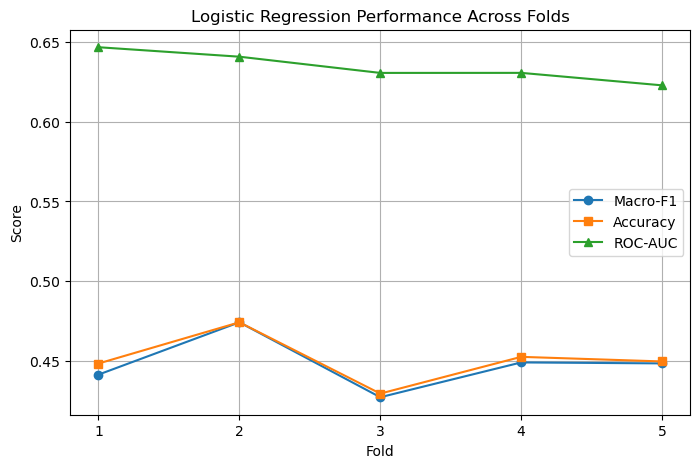


=== SVM ===
Fold 1 - Macro-F1: 0.458, Accuracy: 0.457, ROC-AUC: 0.641
Fold 2 - Macro-F1: 0.491, Accuracy: 0.491, ROC-AUC: 0.687
Fold 3 - Macro-F1: 0.512, Accuracy: 0.516, ROC-AUC: 0.678
Fold 4 - Macro-F1: 0.510, Accuracy: 0.513, ROC-AUC: 0.697
Fold 5 - Macro-F1: 0.465, Accuracy: 0.467, ROC-AUC: 0.664

Overall Macro-F1 Mean = 0.487, Std = 0.022
Overall Accuracy Mean = 0.489, Std = 0.024
Overall ROC-AUC Mean = 0.673, Std = 0.019


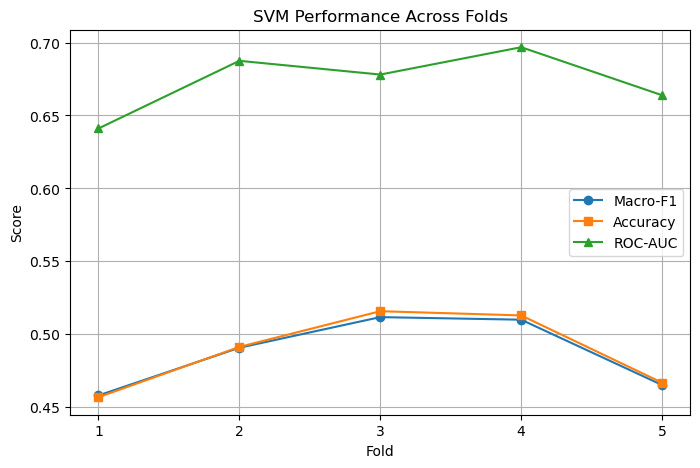


=== Random Forest ===
Fold 1 - Macro-F1: 0.578, Accuracy: 0.580, ROC-AUC: 0.766
Fold 2 - Macro-F1: 0.661, Accuracy: 0.661, ROC-AUC: 0.832
Fold 3 - Macro-F1: 0.637, Accuracy: 0.637, ROC-AUC: 0.803
Fold 4 - Macro-F1: 0.631, Accuracy: 0.631, ROC-AUC: 0.803
Fold 5 - Macro-F1: 0.620, Accuracy: 0.620, ROC-AUC: 0.793

Overall Macro-F1 Mean = 0.625, Std = 0.027
Overall Accuracy Mean = 0.626, Std = 0.026
Overall ROC-AUC Mean = 0.800, Std = 0.021


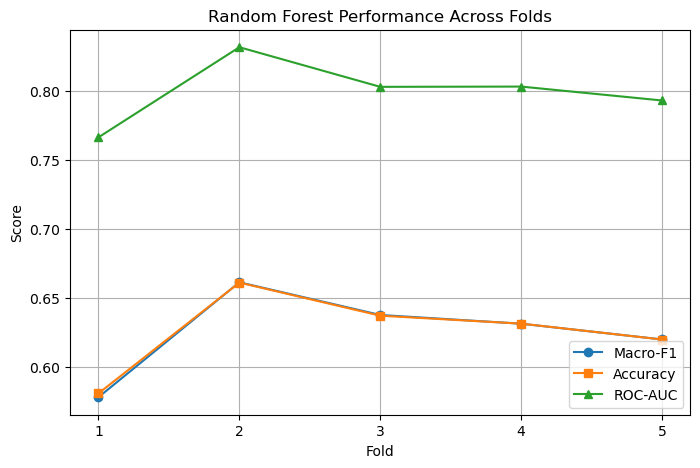


=== XGBoost ===


c:\Users\SANIYA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:44:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1 - Macro-F1: 0.541, Accuracy: 0.540, ROC-AUC: 0.709


c:\Users\SANIYA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:44:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2 - Macro-F1: 0.552, Accuracy: 0.552, ROC-AUC: 0.752


...

Fold 3 - Macro-F1: 0.530, Accuracy: 0.530, ROC-AUC: 0.724


c:\Users\SANIYA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:44:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 4 - Macro-F1: 0.525, Accuracy: 0.524, ROC-AUC: 0.714


c:\Users\SANIYA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:45:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5 - Macro-F1: 0.510, Accuracy: 0.510, ROC-AUC: 0.713

Overall Macro-F1 Mean = 0.531, Std = 0.014
Overall Accuracy Mean = 0.531, Std = 0.014
Overall ROC-AUC Mean = 0.722, Std = 0.016


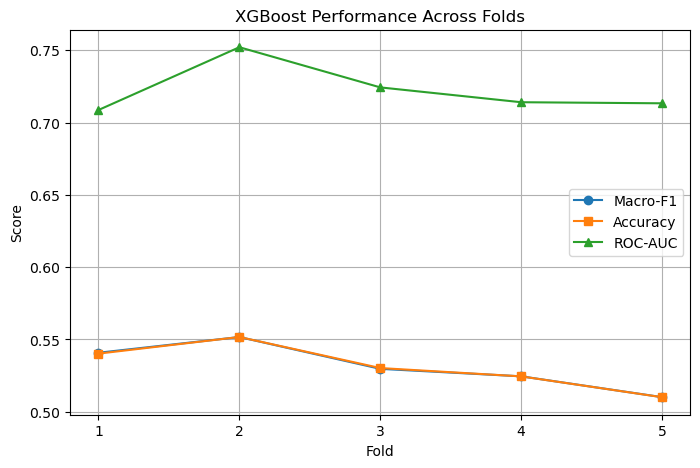


=== LightGBM ===
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002839 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32785
[LightGBM] [Info] Number of data points in the train set: 1389, number of used features: 131
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Fold 1 - Macro-F1: 0.586, Accuracy: 0.589, ROC-AUC: 0.764
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002775 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32778
[LightGBM] [Info] Number of data points in the train set: 1389, number of used features: 131
[LightGBM] [Info] Star

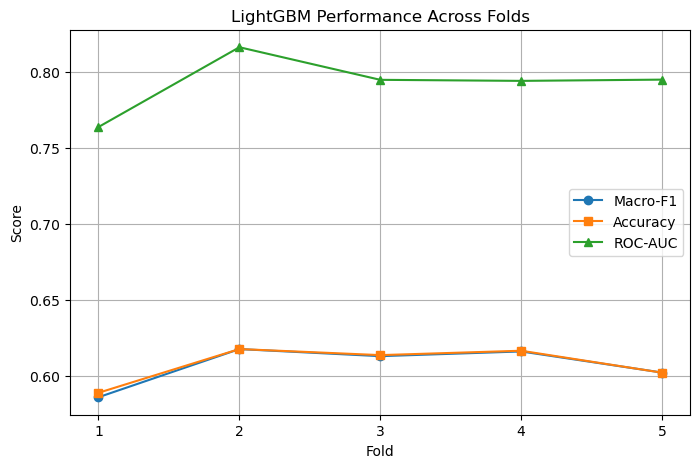


=== CatBoost ===
Fold 1 - Macro-F1: 0.496, Accuracy: 0.497, ROC-AUC: 0.688
Fold 2 - Macro-F1: 0.580, Accuracy: 0.580, ROC-AUC: 0.770
Fold 3 - Macro-F1: 0.543, Accuracy: 0.545, ROC-AUC: 0.728
Fold 4 - Macro-F1: 0.565, Accuracy: 0.565, ROC-AUC: 0.734
Fold 5 - Macro-F1: 0.562, Accuracy: 0.562, ROC-AUC: 0.734

Overall Macro-F1 Mean = 0.549, Std = 0.029
Overall Accuracy Mean = 0.550, Std = 0.029
Overall ROC-AUC Mean = 0.731, Std = 0.026


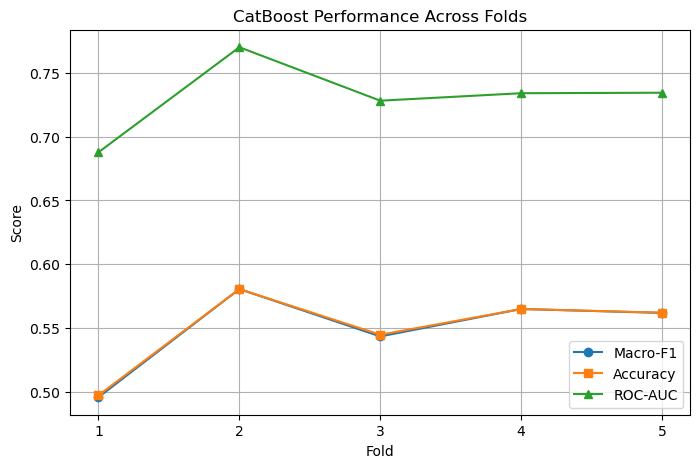

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# --- Define models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=3,
                             use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=200, learning_rate=0.1, num_leaves=31, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=200, learning_rate=0.1, depth=5, verbose=0)
}
X_res = pd.DataFrame(X_res, columns=X.columns)
# --- Binarize target for multi-class ROC-AUC ---
y_bin = label_binarize(y_res, classes=np.unique(y_res))
n_classes = y_bin.shape[1]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Evaluate each model ---
for name, model in models.items():
    print(f"\n=== {name} ===")
    f1_scores = []
    accuracy_scores = []
    roc_auc_scores = []

    fold = 1
    for train_idx, test_idx in cv.split(X_res, y_res):
        X_train, X_test = X_res.iloc[train_idx], X_res.iloc[test_idx]
        y_train, y_test = y_res[train_idx], y_res[test_idx]
        y_test_bin = y_bin[test_idx]

        # Train model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Probabilities for ROC-AUC
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)
        else:  # SVM
            y_prob = model.decision_function(X_test)
            # Convert decision_function to probability-like values
            y_prob = (y_prob - y_prob.min(axis=1).reshape(-1,1)) / \
                     (y_prob.max(axis=1).reshape(-1,1) - y_prob.min(axis=1).reshape(-1,1) + 1e-6)

        # Compute metrics
        f1_scores.append(f1_score(y_test, y_pred, average='macro'))
        accuracy_scores.append(accuracy_score(y_test, y_pred))
        try:
            roc_auc_scores.append(roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr'))
        except:
            roc_auc_scores.append(np.nan)  # handle models that fail ROC-AUC

        print(f"Fold {fold} - Macro-F1: {f1_scores[-1]:.3f}, Accuracy: {accuracy_scores[-1]:.3f}, ROC-AUC: {roc_auc_scores[-1]:.3f}")
        fold += 1

    print(f"\nOverall Macro-F1 Mean = {np.mean(f1_scores):.3f}, Std = {np.std(f1_scores):.3f}")
    print(f"Overall Accuracy Mean = {np.mean(accuracy_scores):.3f}, Std = {np.std(accuracy_scores):.3f}")
    print(f"Overall ROC-AUC Mean = {np.nanmean(roc_auc_scores):.3f}, Std = {np.nanstd(roc_auc_scores):.3f}")

    # --- Plot trends ---
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(f1_scores)+1), f1_scores, marker='o', label='Macro-F1')
    plt.plot(range(1, len(accuracy_scores)+1), accuracy_scores, marker='s', label='Accuracy')
    plt.plot(range(1, len(roc_auc_scores)+1), roc_auc_scores, marker='^', label='ROC-AUC')
    plt.xticks(range(1, len(f1_scores)+1))
    plt.xlabel("Fold")
    plt.ylabel("Score")
    plt.title(f"{name} Performance Across Folds")
    plt.legend()
    plt.grid(True)
    plt.show()


> **Logistic Regression**  
> Fold 1 - Macro-F1: 0.327, Accuracy: 0.333, ROC-AUC: 0.521  
> Fold 2 - Macro-F1: 0.364, Accuracy: 0.365, ROC-AUC: 0.528  
> Fold 3 - Macro-F1: 0.327, Accuracy: 0.331, ROC-AUC: 0.504  
> Fold 4 - Macro-F1: 0.338, Accuracy: 0.343, ROC-AUC: 0.524  
> Fold 5 - Macro-F1: 0.378, Accuracy: 0.383, ROC-AUC: 0.550  
> Overall Macro-F1 Mean = 0.347, Std = 0.021  
> Overall Accuracy Mean = 0.351, Std = 0.020  
> Overall ROC-AUC Mean = 0.525, Std = 0.015  

> **SVM**  
> Fold 1 - Macro-F1: 0.336, Accuracy: 0.342, ROC-AUC: 0.532  
> Fold 2 - Macro-F1: 0.376, Accuracy: 0.385, ROC-AUC: 0.561  
> Fold 3 - Macro-F1: 0.347, Accuracy: 0.352, ROC-AUC: 0.531  
> Fold 4 - Macro-F1: 0.358, Accuracy: 0.357, ROC-AUC: 0.554  
> Fold 5 - Macro-F1: 0.414, Accuracy: 0.418, ROC-AUC: 0.609  
> Overall Macro-F1 Mean = 0.366, Std = 0.027  
> Overall Accuracy Mean = 0.371, Std = 0.028  
> Overall ROC-AUC Mean = 0.558, Std = 0.028  

> **Random Forest**  
> Fold 1 - Macro-F1: 0.489, Accuracy: 0.489, ROC-AUC: 0.687  
> Fold 2 - Macro-F1: 0.538, Accuracy: 0.540, ROC-AUC: 0.700  
> Fold 3 - Macro-F1: 0.503, Accuracy: 0.504, ROC-AUC: 0.669  
> Fold 4 - Macro-F1: 0.547, Accuracy: 0.548, ROC-AUC: 0.708  
> Fold 5 - Macro-F1: 0.542, Accuracy: 0.542, ROC-AUC: 0.723  
> Overall Macro-F1 Mean = 0.524, Std = 0.024  
> Overall Accuracy Mean = 0.524, Std = 0.024  
> Overall ROC-AUC Mean = 0.697, Std = 0.019  

> **XGBoost**  
> Fold 5 - Macro-F1: 0.466, Accuracy: 0.467, ROC-AUC: 0.640  
> Overall Macro-F1 Mean = 0.442, Std = 0.023  
> Overall Accuracy Mean = 0.443, Std = 0.023  
> Overall ROC-AUC Mean = 0.613, Std = 0.018  

> **LightGBM**  
> Overall Macro-F1 Mean = 0.492, Std = 0.030  
> Overall Accuracy Mean = 0.493, Std = 0.030  
> Overall ROC-AUC Mean = 0.663, Std = 0.020  

> **CatBoost**  
> Fold 1 - Macro-F1: 0.427, Accuracy: 0.428, ROC-AUC: 0.609  
> Fold 2 - Macro-F1: 0.491, Accuracy: 0.491, ROC-AUC: 0.661  
> Fold 3 - Macro-F1: 0.456, Accuracy: 0.458, ROC-AUC: 0.632  
> Fold 4 - Macro-F1: 0.514, Accuracy: 0.516, ROC-AUC: 0.671  
> Fold 5 - Macro-F1: 0.463, Accuracy: 0.464, ROC-AUC: 0.646  
> Overall Macro-F1 Mean = 0.470, Std = 0.030  
> Overall Accuracy Mean = 0.472, Std = 0.030  
> Overall ROC-AUC Mean = 0.644, Std = 0.022  


In [3]:
print(best_gb)  # should output your trained model object


GradientBoostingClassifier(learning_rate=np.float64(0.01691872751242473),
                           max_depth=5, min_samples_leaf=3, min_samples_split=3,
                           n_estimators=675, random_state=42,
                           subsample=np.float64(0.9921266556524377))


In [4]:
import os
import pickle

# Make sure the folder exists
os.makedirs("../models", exist_ok=True)

# Path to save the model
model_path = "../models/gradient_boosting_model.pkl"

# Save the model
with open(model_path, "wb") as f:
    pickle.dump(best_gb, f)

print(f"Model saved successfully at {model_path}")


Model saved successfully at ../models/gradient_boosting_model.pkl


##### **Final Outcome**
For participant 1- <br>
SVM and Logistic Regression appear best based on metrics, but these results are not reliable because of the extremely small test set—they are likely overfitting.
Gradient Boosting and Random Forest are more realistic choices because they generalize better on small datasets and still show strong performance.

For participants 1 to 38 - <br>
Random Forest has the highest Macro-F1 (0.524), highest Accuracy (0.524), and highest ROC-AUC (0.697) among all models.
Macro-F1 is important if your classes are imbalanced—it shows the balance between precision and recall across all classes.
Accuracy gives the overall correctness.
ROC-AUC measures the model's ability to distinguish between classes.